# Module 1 — Notebook 1: Text Preprocessing Pipeline

**Covers:** Theory sections 1, 2 · Week 1 slides · Week 2 Lab (Part 2)

**Goal:** Understand and implement every step that transforms a raw OpenSanctions entity record  
into a clean list of index terms — exactly what `src/preprocessing/` does in Phase 2.

| Step | Input | Output |
|------|-------|--------|
| 0 | Raw JSON record | — |
| 1 | Raw text | Tokens |
| 2 | Tokens | Normalised tokens |
| 3 | Normalised tokens | Content tokens (stop words removed) |
| 4 | Content tokens | Root forms (stemmed / lemmatised) |
| 5 | All corpus tokens | Vocabulary statistics (Zipf, Heap) |

**Continues in:** `02_indexing_boolean_retrieval.ipynb`

---
## End-to-end schema and consumers (Phase 2 + downstream)

Each flattened record from `src/preprocessing/document_builder.build_document` supplies fields used by different retrieval stages:

| Output field | BM25 | TF-IDF | Identifier | Dense (today) | RRF |
|--------------|------|--------|------------|-----------------|-----|
| `tokens` | Yes (`rank-bm25`) | — | — | — | — |
| `text_blob` | — | Yes (`TfidfVectorizer`) | — | — | — |
| `identifiers` | — | — | Yes (exact lookup) | — | — |
| `metadata` (`country`, `programId`, `datasets`) | Filtering / display; Type 6 qrels | — | — | Context in notebook 07a + Chroma metadata | — |
| `caption`, `schema` | Display | — | — | 07a `build_doc_text` + Chroma rows | — |
| **Ranked runs** | — | — | — | — | **Yes** — RRF reads CSV columns `query_id`, `doc_id`, `rank` from each retriever; it does **not** read `documents.jsonl`. |

Dense retrieval encodes **natural-language text** built from the same entity fields (see `notebooks/07a_dense_retrieval_creation_4_0_github.ipynb`). A future optional field `dense_text` in preprocessing would centralize that text so notebook 07a only loads and encodes.


In [1]:
# ── Setup — run this cell first ───────────────────────────────────────────────
import json, re, unicodedata, math
from collections import Counter, defaultdict
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt', quiet=True)
nltk.download('wordnet', quiet=True)
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

import spacy
try:
    nlp = spacy.load('en_core_web_sm')
except OSError:
    import subprocess, sys
    subprocess.run([sys.executable, '-m', 'spacy', 'download', 'en_core_web_sm'], check=True)
    nlp = spacy.load('en_core_web_sm')

STOP_WORDS = set(stopwords.words('english'))
stemmer    = PorterStemmer()
print('Setup complete.')

Setup complete.


---
## Sample Dataset — 100 Real OpenSanctions Records

All examples in this notebook use **100 real OpenSanctions entity records** loaded from  
`data/raw_data/sample_targets.json`. These are the same records the production pipeline  
(`src/preprocessing/`) processes at scale — just a small slice.

Each record is a **nested JSON object**:

| Top-level field | Description |
|-----------------|-------------|
| `id` | Unique entity identifier (e.g. `NK-...`) |
| `caption` | Human-readable primary name |
| `schema` | Entity type: `Person`, `Company`, `Vessel`, … |
| `properties` | Dict containing all entity attributes (names, topics, etc.) |

Key fields inside `properties.name`, `.alias`, `.topics`, `.notes`, `.imoNumber`, …

Helper functions loaded with the data (`get_names`, `get_desc`, `get_topics`, `get_primary_text`)  
give clean access to these nested fields throughout the notebook.

In [2]:
from pathlib import Path

# ── Locate the data file regardless of kernel working directory ────────────
# Cursor/VS Code Jupyter may use project root OR notebook dir as cwd.
# We search upward until we find the file.
def _find_file(*parts):
    """Walk up from cwd until a relative path resolves to an existing file."""
    p = Path.cwd()
    for _ in range(8):
        candidate = p.joinpath(*parts)
        if candidate.exists():
            return candidate
        p = p.parent
    raise FileNotFoundError(
        f"Could not find {'/' .join(parts)} — cwd was {Path.cwd()}"
    )

SAMPLE_PATH = _find_file("data", "raw_data", "sample_targets.json")
print(f"Found data at: {SAMPLE_PATH}")

# ── Load the real sample data ──────────────────────────────────────────────
RAW_DOCS = [json.loads(line) for line in SAMPLE_PATH.open(encoding="utf-8")]
MINI_CORPUS = RAW_DOCS  # alias used throughout this notebook

# ── Field accessor helpers for the nested properties schema ───────────────
def get_names(record):
    """All name + alias string values from a record."""
    props = record.get('properties', {})
    vals = []
    for field in ['name', 'alias', 'previousName']:
        vals.extend(v for v in props.get(field, []) if isinstance(v, str) and v.strip())
    return vals

def get_desc(record):
    """Concatenated free-text (notes / description / summary), or empty string."""
    props = record.get('properties', {})
    parts = []
    for field in ['notes', 'description', 'summary']:
        parts.extend(v for v in props.get(field, []) if isinstance(v, str))
    return ' '.join(parts).strip()

def get_topics(record):
    """Topic keyword strings."""
    return [v for v in record.get('properties', {}).get('topics', []) if isinstance(v, str)]

def get_primary_text(record):
    """Names + description + topics joined — always returns something."""
    return ' '.join(filter(None, get_names(record) + [get_desc(record)] + get_topics(record)))

print(f'Loaded {len(MINI_CORPUS)} records from sample_targets.json')
print(f"\n{'ID':<36} {'Schema':<15} {'Caption'}")
print('-' * 75)
for e in MINI_CORPUS[:12]:
    print(f"{e['id']:<36} {e['schema']:<15} {e['caption'][:30]}")
print(f'  ... ({len(MINI_CORPUS) - 12} more records)')

Found data at: /Users/alireza/Library/CloudStorage/GoogleDrive-ali.esterabi@gmail.com/My Drive/QMUL_temr_2/IR_project/data/raw_data/sample_targets.json
Loaded 100 records from sample_targets.json

ID                                   Schema          Caption
---------------------------------------------------------------------------
NK-223CQDBzp8MRkdJMDiqXn3            Company         Myanmar Yatai International Ho
NK-223yQP6hRaMuiALDCJ6xbY            Company         Товариство з обмеженою відпові
NK-224TRezPqwzhQZ37exWxtX            Person          SANAVBARI NIKITENKO
NK-226GXBdQ5p6NjgrTpTQNVW            Company         Open Joint Stock Company “Elek
NK-228ZdYZVXaZBSBgVwapnks            Company         Приватне підприємство "Магіста
NK-228jBYSTdUSvbZvsKsiHh6            Company         Акціонерне товариство "Електро
NK-229j9NEWBexje4PuNpeHxg            LegalEntity     MICHAEL DAVID MUMMERT
NK-22BiLDQqi5mhKfDeYuqs23            Person          ARNITA LEFF
NK-22C9zkXEo48ioJPccyPR4c        

In [3]:
# Inspect the nested structure of one real record
sample = MINI_CORPUS[0]
print(f"{'─'*60}")
print(f"id       : {sample['id']}")
print(f"caption  : {sample['caption']}")
print(f"schema   : {sample['schema']}")
print(f"datasets : {sample.get('datasets', [])[:3]}")
print(f"{'─'*60}")
props = sample.get('properties', {})
print(f"\nproperties ({len(props)} keys):")
for key in ['name', 'alias', 'topics', 'country', 'notes', 'description', 'sector', 'imoNumber', 'mmsi']:
    vals = props.get(key)
    if vals:
        preview = vals[:3]
        print(f"  {key:<18}: {preview}{'...' if len(vals) > 3 else ''}")
print(f"\n--- via helper functions ---")
print(f"get_names()        → {get_names(sample)[:4]}")
print(f"get_desc()         → {get_desc(sample)[:80]!r}")
print(f"get_topics()       → {get_topics(sample)}")
print(f"get_primary_text() → {get_primary_text(sample)[:80]!r}...")

────────────────────────────────────────────────────────────
id       : NK-223CQDBzp8MRkdJMDiqXn3
caption  : Myanmar Yatai International Holding Group Co., LTD.
schema   : Company
datasets : ['us_trade_csl', 'opencorporates', 'us_ofac_sdn']
────────────────────────────────────────────────────────────

properties (16 keys):
  name              : ['Yatai New City', 'Myanmar Yatai International Holding Group Co., Ltd', 'SHWE KOKKO SPECIAL ECONOMIC ZONE']...
  alias             : ['Yatai Smart Industrial New City', 'Yatai New City', 'Shwe Kokko Special Economic Zone']
  topics            : ['sanction', 'debarment']
  country           : ['mm']
  notes             : ['(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART INDUSTRIAL NEW CITY)', '(also MYANMAR YATAI INTERNATIONAL HOLDING GROUP CO., LTD.)']
  sector            : ['Construction of buildings']

--- via helper functions ---
get_names()        → ['Yatai New City', 'Myanmar Yatai International Holding Group Co., Ltd',

---
## Section 1: What is Information Retrieval?

**Definition (Manning et al., Chapter 1):**
> Information Retrieval is finding material (usually documents) of an unstructured nature that satisfies an information need from within large collections stored on computers.

### Why not just use grep?

| Approach | Mechanism | Problem |
|----------|-----------|--------|
| `grep` / linear scan | O(N × doc_length) | Hours on 3.7 GB file |
| SQL `LIKE '%query%'` | No index used | Full table scan |
| **Inverted index** | O(query_terms) | Sub-millisecond ✓ |

### Evaluation: Precision and Recall

$$\text{Precision} = \frac{|\text{Retrieved} \cap \text{Relevant}|}{|\text{Retrieved}|}$$

$$\text{Recall} = \frac{|\text{Retrieved} \cap \text{Relevant}|}{|\text{Relevant}|}$$

$$F_1 = \frac{2 \cdot P \cdot R}{P + R}$$

In [4]:
# Precision & Recall on the toy corpus
# Query: "Russian sanctions"
# Ground truth: E001, E005, E008 (Russian-linked sanctioned entities)

RELEVANT = {"E001", "E005", "E008"}

RETRIEVED_NAIVE  = {"E001", "E003", "E008"}            # missed E005, false positive E003
RETRIEVED_BETTER = {"E001", "E005", "E008", "E003"}    # all relevant + one false positive
RETRIEVED_PERFECT = {"E001", "E005", "E008"}            # exact match

def precision_recall_f1(retrieved: set, relevant: set) -> dict:
    tp = retrieved & relevant
    p  = len(tp) / len(retrieved) if retrieved else 0.0
    r  = len(tp) / len(relevant)  if relevant  else 0.0
    f1 = 2*p*r/(p+r) if (p+r) > 0 else 0.0
    return {'precision': p, 'recall': r, 'f1': f1, 'tp': tp}

print(f'Ground truth relevant: {RELEVANT}\n')
for name, ret in [('Naive system',  RETRIEVED_NAIVE),
                  ('Better system', RETRIEVED_BETTER),
                  ('Perfect',       RETRIEVED_PERFECT)]:
    m = precision_recall_f1(ret, RELEVANT)
    print(f'{name:<16}  P={m["precision"]:.2f}  R={m["recall"]:.2f}  F1={m["f1"]:.2f}  TP={m["tp"]}')

Ground truth relevant: {'E005', 'E001', 'E008'}

Naive system      P=0.67  R=0.67  F1=0.67  TP={'E001', 'E008'}
Better system     P=0.75  R=1.00  F1=0.86  TP={'E005', 'E001', 'E008'}
Perfect           P=1.00  R=1.00  F1=1.00  TP={'E005', 'E001', 'E008'}


**Key insight:** Precision and Recall trade off against each other.
- Returning *everything* → Recall = 1.0, Precision → 0
- Returning *nothing* → both = 0
- Good IR systems balance both — hence F₁.

---
## Section 2: Text Processing Pipeline

```
Raw text → [2a] Tokenize → [2b] Normalise → [2c] Remove stop words → [2d] Stem/Lemmatise → Tokens
```

### 2a. Document Delineation & Tokenization

**Document delineation** (Manning §2.1): deciding what counts as one document.  
For OpenSanctions, each entity record = one document.

**Tokenization** (Manning §2.2): splitting a character sequence into **tokens** (words/terms).

Simple rule: split on whitespace. But naive splitting fails on:
- Punctuation: `"sanctions,"` → should be `"sanctions"`
- Hyphens: `"oil-smuggling"` — one token or two?
- Possessives: `"OFAC's"` → `"OFAC"` + `"'s"` or just `"OFAC"`?
- Scripts without spaces: `"新疆纺织"` (Chinese)

In [5]:
# 2a. Tokenization: naive split vs spaCy
sample_text = "Black Sea Trading Corp. (BSTC) used oil-smuggling routes; evading OFAC's sanctions since 2019."

# Naive split on whitespace
naive_tokens = sample_text.split()
print(f"NAIVE split() — {len(naive_tokens)} tokens:")
print(naive_tokens)
print("  Problems: 'Corp.' keeps period, \"OFAC's\" keeps possessive, 'oil-smuggling' is hyphenated\n")

# spaCy tokenizer — handles language rules
doc_spacy = nlp(sample_text)
spacy_tokens = [t.text for t in doc_spacy]
print(f"spaCy tokenizer — {len(spacy_tokens)} tokens:")
print(spacy_tokens)
print("  spaCy correctly splits punctuation and handles possessives\n")

# Regex tokenizer — fast middle ground
regex_tokens = re.findall(r"[\w']+", sample_text)
print(f"Regex [\\w']+ — {len(regex_tokens)} tokens:")
print(regex_tokens)

NAIVE split() — 13 tokens:
['Black', 'Sea', 'Trading', 'Corp.', '(BSTC)', 'used', 'oil-smuggling', 'routes;', 'evading', "OFAC's", 'sanctions', 'since', '2019.']
  Problems: 'Corp.' keeps period, "OFAC's" keeps possessive, 'oil-smuggling' is hyphenated

spaCy tokenizer — 20 tokens:
['Black', 'Sea', 'Trading', 'Corp.', '(', 'BSTC', ')', 'used', 'oil', '-', 'smuggling', 'routes', ';', 'evading', 'OFAC', "'s", 'sanctions', 'since', '2019', '.']
  spaCy correctly splits punctuation and handles possessives

Regex [\w']+ — 14 tokens:
['Black', 'Sea', 'Trading', 'Corp', 'BSTC', 'used', 'oil', 'smuggling', 'routes', 'evading', "OFAC's", 'sanctions', 'since', '2019']


In [6]:
# Tokenization on MINI_CORPUS — primary text (names + desc + topics) per record
print(f"{'Schema':<12} {'Caption':<32} {'naive':>6} {'spaCy':>6} {'regex':>6}")
print("-" * 62)
for e in MINI_CORPUS[:10]:
    text  = get_primary_text(e)
    naive = len(text.split())
    spa   = len([t for t in nlp(text) if not t.is_space])
    rgx   = len(re.findall(r'[\w]+', text))
    print(f"{e['schema']:<12} {e['caption'][:31]:<32} {naive:>6} {spa:>6} {rgx:>6}")

Schema       Caption                           naive  spaCy  regex
--------------------------------------------------------------
Company      Myanmar Yatai International Hol      64     76     64
Company      Товариство з обмеженою відповід      24     32     24
Person       SANAVBARI NIKITENKO                   4      4      4
Company      Open Joint Stock Company “Elekt     413    559    471
Company      Приватне підприємство "Магістар      15     35     20
Company      Акціонерне товариство "Електроа      23     37     24
LegalEntity  MICHAEL DAVID MUMMERT                10     11     12
Person       ARNITA LEFF                           6      6      6
Vessel       DONG CHANG                            3      3      4
Person       Michael Kuajien                      28     34     28


### 2b. Normalization

**Goal:** Map different surface forms to the same canonical term.  
(Manning §2.2.3)

| Step | Input | Output | Why |
|------|-------|--------|-----|
| Case folding | `OFAC` | `ofac` | `OFAC` = `Ofac` = `ofac` |
| Unicode NFC | `e\u0301` | `é` | Two code points → one |
| Accent strip | `café` | `cafe` | Diacritic-insensitive matching |
| ASCII transliteration | `Виктор` | `viktor` | Cyrillic → Latin |
| Remove punctuation | `U.S.A.` | `usa` | Normalise acronyms |

**Key for OpenSanctions:** Many entities have names in Arabic, Russian, Chinese.  
A search for `"Viktor"` should still match `"Виктор"`.

In [7]:
# 2b. Normalization function
def normalize(text: str) -> str:
    """Lowercase + unicode NFC + strip diacritics + remove punctuation + collapse whitespace."""
    text = unicodedata.normalize('NFC', text)       # compose characters
    text = text.lower()                             # case fold
    text = unicodedata.normalize('NFD', text)       # decompose for accent removal
    text = ''.join(c for c in text if unicodedata.category(c) != 'Mn')  # drop combining marks
    text = re.sub(r'[^\w\s]', ' ', text)            # remove punctuation
    text = re.sub(r'\s+', ' ', text).strip()        # collapse whitespace
    return text

# Test cases
test_cases = [
    ("OFAC Sanctions",         "uppercase acronym"),
    ("café au lait",           "diacritics"),
    ("Виктор Петров",          "Cyrillic"),
    ("فاطمة الراشدي",          "Arabic"),
    ("U.S.A. sanctions 2019.", "punctuation + numbers"),
    ("oil-smuggling routes;",  "hyphen + semicolon"),
]

print(f"{'Input':<30} {'Normalised output'}")
print("-" * 60)
for text, label in test_cases:
    print(f"{text:<30} → '{normalize(text)}'   [{label}]")

Input                          Normalised output
------------------------------------------------------------
OFAC Sanctions                 → 'ofac sanctions'   [uppercase acronym]
café au lait                   → 'cafe au lait'   [diacritics]
Виктор Петров                  → 'виктор петров'   [Cyrillic]
فاطمة الراشدي                  → 'فاطمة الراشدي'   [Arabic]
U.S.A. sanctions 2019.         → 'u s a sanctions 2019'   [punctuation + numbers]
oil-smuggling routes;          → 'oil smuggling routes'   [hyphen + semicolon]


In [8]:
# Apply normalization to entity names — first 6 records, up to 3 names each
print("Normalized names from MINI_CORPUS (first 6 records):\n")
for e in MINI_CORPUS[:6]:
    names = get_names(e)[:3]
    print(f"{e['id'][:20]} {e['caption'][:30]}")
    for n in names:
        print(f"   raw: {n!r:40s}  →  normalised: '{normalize(n)}'")
    print()

Normalized names from MINI_CORPUS (first 6 records):

NK-223CQDBzp8MRkdJMD Myanmar Yatai International Ho
   raw: 'Yatai New City'                          →  normalised: 'yatai new city'
   raw: 'Myanmar Yatai International Holding Group Co., Ltd'  →  normalised: 'myanmar yatai international holding group co ltd'
   raw: 'SHWE KOKKO SPECIAL ECONOMIC ZONE'        →  normalised: 'shwe kokko special economic zone'

NK-223yQP6hRaMuiALDC Товариство з обмеженою відпові
   raw: 'Товариство з обмеженою відповідальністю "Зелінський Групп"'  →  normalised: 'товариство з обмеженою відповідальністю зелінськии групп'
   raw: 'Общество с ограниченной ответственностью "Зелинский Групп"'  →  normalised: 'общество с ограниченнои ответственностью зелинскии групп'
   raw: 'Limited Liability Company "Zelinsky Group"'  →  normalised: 'limited liability company zelinsky group'

NK-224TRezPqwzhQZ37e SANAVBARI NIKITENKO
   raw: 'SANAVBARI NIKITENKO'                     →  normalised: 'sanavbari nikitenko'

N

### 2c. Stop Words

**Stop words** (Manning §2.2.2): extremely common words with little discriminative value  
(*a, the, is, of, in, at...*).

**Why remove them?**
- Account for 20–30% of all tokens → huge, useless postings lists
- `the` appears in nearly every document → useless for ranking

**When to keep them?**
- Phrase queries: `"to be or not to be"`
- Named entities: `"The Who"`, `"Take That"`

**For OpenSanctions:** Remove stop words from `notes`/`description` but  
**never** from entity names — `"The Kremlin"` must remain intact.

In [9]:
# 2c. Stop word removal
def remove_stopwords(tokens: list) -> list:
    return [t for t in tokens if t.lower() not in STOP_WORDS and len(t) > 1]

print(f"NLTK English stop word list: {len(STOP_WORDS)} words")
print(f"Sample: {sorted(STOP_WORDS)[:20]}\n")
print("Stop word removal on description / primary text (first 6 non-empty records):\n")

shown = 0
for e in MINI_CORPUS:
    text = get_desc(e) or get_primary_text(e)
    if not text:
        continue
    raw_tokens = normalize(text).split()
    filtered   = remove_stopwords(raw_tokens)
    removed    = [t for t in raw_tokens if t not in filtered]
    print(f"{e['schema']:<12} {e['caption'][:30]}")
    preview_raw = ' '.join(raw_tokens[:12]) + ('...' if len(raw_tokens) > 12 else '')
    preview_fil = ' '.join(filtered[:12])   + ('...' if len(filtered)   > 12 else '')
    print(f"  Before ({len(raw_tokens):3d}): {preview_raw}")
    print(f"  After  ({len(filtered):3d}): {preview_fil}")
    print(f"  Removed: {removed[:8]}")
    print()
    shown += 1
    if shown >= 6:
        break

NLTK English stop word list: 198 words
Sample: ['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been']

Stop word removal on description / primary text (first 6 non-empty records):

Company      Myanmar Yatai International Ho
  Before ( 22): also shwe kokko special economic zone yatai new city yatai smart industrial...
  After  ( 22): also shwe kokko special economic zone yatai new city yatai smart industrial...
  Removed: []

Company      Товариство з обмеженою відпові
  Before ( 24): товариство з обмеженою відповідальністю зелінськии групп общество с ограниченнои ответственностью зелинскии групп...
  After  ( 21): товариство обмеженою відповідальністю зелінськии групп общество ограниченнои ответственностью зелинскии групп limited liability...
  Removed: ['з', 'с', 'z']

Person       SANAVBARI NIKITENKO
  Before (  4): sanavbari nikitenko wanted crime
  After  (  4): sanavbari nikitenko 

In [10]:
# Lab exercise (from Week 2 Lab Q2): Build a vocabulary using a set
# Why a set and not a list? → sets automatically deduplicate

# Use primary text (names + desc + topics) for every record
all_texts = [get_primary_text(e) for e in MINI_CORPUS if get_primary_text(e)]

# Build vocabulary two ways — they should be identical
vocab_loop = set()
for text in all_texts:
    for word in normalize(text).split():
        vocab_loop.add(word)

# Equivalent one-liner
vocab_oneliner = set(word for text in all_texts for word in normalize(text).split())

print(f'Records with text : {len(all_texts)} of {len(MINI_CORPUS)}')
print(f'Vocabulary size   : {len(vocab_loop)}')
print(f'One-liner matches : {vocab_loop == vocab_oneliner}')
print(f'Sample terms      : {sorted(vocab_loop)[:20]}')

Records with text : 100 of 100
Vocabulary size   : 1079
One-liner matches : True
Sample terms      : ['00', '0054548', '0082825', '0104002', '04', '05', '06', '07', '08', '09', '1', '10', '1025007108390', '1110', '1192', '13', '144001', '17', '18', '1994']


### 2d. Stemming vs Lemmatization

Both reduce words to a base form, but via different mechanisms.  
(Manning §2.2.4–2.2.5)

| | Stemming | Lemmatization |
|---|---|---|
| Method | Chop suffixes (rules) | Dictionary lookup + POS tagging |
| `running` | `run` | `run` |
| `better` | `better` | `good` |
| `sanctions` | `sanction` | `sanction` |
| `evading` | `evad` | `evade` |
| Speed | Fast | Slower (POS needed) |
| Accuracy | Lower | Higher |

**Critical for OpenSanctions (from Phase 2 design):**
- Apply **lemmatization** to `notes` and `description` (free text) → better recall
- **Do NOT lemmatize entity names** — `"sanctions"` in a name is a proper noun

In [11]:
# 2d. Stemming vs Lemmatization — direct comparison
test_sentences = [
    "The company was evading sanctions by transferring funds.",
    "Vessels suspected of smuggling crude oil were sanctioned.",
    "He is financing terrorism through illegal organizations.",
]

print(f"{'Token':<15} {'Porter Stem':<15} {'spaCy Lemma':<15} {'POS':<6} {'Different?'}")
print("-" * 70)

for sent in test_sentences:
    doc = nlp(sent)
    print(f"\n>> {sent}")
    for token in doc:
        if token.is_alpha and not token.is_stop:
            stem  = stemmer.stem(token.text)
            lemma = token.lemma_
            flag  = " ← different!" if stem != lemma else ""
            print(f"  {token.text:<15} {stem:<15} {lemma:<15} {token.pos_:<6}{flag}")

Token           Porter Stem     spaCy Lemma     POS    Different?
----------------------------------------------------------------------

>> The company was evading sanctions by transferring funds.
  company         compani         company         NOUN   ← different!
  evading         evad            evade           VERB   ← different!
  sanctions       sanction        sanction        NOUN  
  transferring    transfer        transfer        VERB  
  funds           fund            fund            NOUN  

>> Vessels suspected of smuggling crude oil were sanctioned.
  Vessels         vessel          vessel          NOUN  
  suspected       suspect         suspect         VERB  
  smuggling       smuggl          smuggle         VERB   ← different!
  crude           crude           crude           ADJ   
  oil             oil             oil             NOUN  
  sanctioned      sanction        sanction        VERB  

>> He is financing terrorism through illegal organizations.
  financing  

In [12]:
# Compare: stemmed vs lemmatized on real MINI_CORPUS description text
# Use first 3 records that have non-empty description
records_with_desc = [e for e in MINI_CORPUS if get_desc(e)][:3]
if not records_with_desc:
    records_with_desc = MINI_CORPUS[:3]  # fallback to names

print("Stemmed vs Lemmatised — first 3 records with description:\n")
for e in records_with_desc:
    raw  = get_desc(e) or get_primary_text(e)
    text = normalize(raw)
    stemmed    = [stemmer.stem(t) for t in text.split() if t not in STOP_WORDS]
    doc        = nlp(text)
    lemmatised = [t.lemma_ for t in doc if t.is_alpha and not t.is_stop]
    preview    = raw[:70] + ('...' if len(raw) > 70 else '')
    print(f"{e['schema'][:10]} '{e['caption'][:28]}': \"{preview}\"")
    print(f"  Stemmed   : {stemmed[:10]}")
    print(f"  Lemmatised: {lemmatised[:10]}")
    print()

Stemmed vs Lemmatised — first 3 records with description:

Company 'Myanmar Yatai International ': "(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART IN..."
  Stemmed   : ['also', 'shwe', 'kokko', 'special', 'econom', 'zone', 'yatai', 'new', 'citi', 'yatai']
  Lemmatised: ['shwe', 'kokko', 'special', 'economic', 'zone', 'yatai', 'new', 'city', 'yatai', 'smart']



Company 'Open Joint Stock Company “El': "Adresse : 144001, Fédération de Russie, région de Moscou, Electrostal,..."
  Stemmed   : ['adress', '144001', 'feder', 'de', 'russi', 'region', 'de', 'moscou', 'electrost', 'karl']
  Lemmatised: ['adresse', 'federation', 'de', 'russie', 'region', 'de', 'moscou', 'electrostal', 'karl', 'marx']

LegalEntit 'MICHAEL DAVID MUMMERT': "ADDITION, F.R. NOTICE ADDED Standard"
  Stemmed   : ['addit', 'f', 'r', 'notic', 'ad', 'standard']
  Lemmatised: ['addition', 'f', 'r', 'notice', 'add', 'standard']



---
## Section 3: Statistical Laws — Zipf's Law & Heap's Law

Two fundamental laws govern word frequency distributions in any text corpus.  
(Manning §5.1)

### 3a. Zipf's Law

**Statement:** The $i$-th most frequent term has frequency proportional to $1/i$:

$$cf_i \propto \frac{1}{i^\alpha}, \quad \alpha \approx 1$$

**Log-log form (linear!):**
$$\log(cf_i) = \log(c) - \alpha \cdot \log(i)$$

**Practical implications:**
1. Top ~150 terms account for ~50% of all token occurrences (→ stop word candidates)
2. Most terms appear only once (*hapax legomena*) → sparse index
3. Index compression exploits this distribution (Section 6 of next notebook)

Total tokens: 2426, Unique terms: 804

Top 15 terms (high frequency = stop word candidates):
Rank   Term                  Freq    % total
---------------------------------------------
1      the                     62       2.6%
2      sanction                54       2.2%
3      debarment               52       2.1%
4      of                      49       2.0%
5      donise                  48       2.0%
6      warren                  39       1.6%
7      d                       34       1.4%
8      and                     32       1.3%
9      company                 25       1.0%
10     a                       21       0.9%
11     also                    20       0.8%
12     in                      19       0.8%
13     al                      19       0.8%
14     ltd                     18       0.7%
15     on                      17       0.7%

Fitted Zipf exponent: α = 0.80  (ideal ≈ 1.0)
  → log(freq) = 5.20 + -0.80 × log(rank)


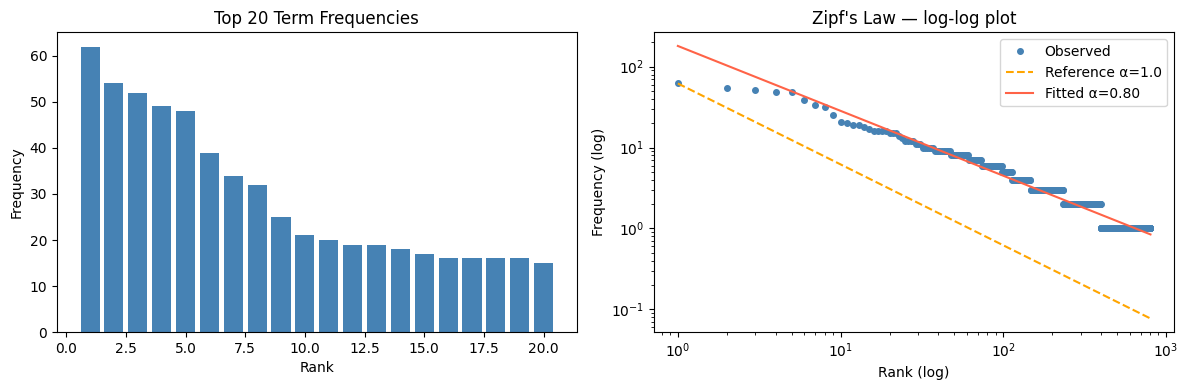

In [13]:
# ── Change this to experiment with different slopes ───────────────────────
ZIPF_ALPHA = 1.0   # classical Zipf; try 0.7, 1.2, 1.5, …
# ─────────────────────────────────────────────────────────────────────────

# 3a. Zipf's Law on MINI_CORPUS — use all available text per record
all_tokens = []
for e in MINI_CORPUS:
    text = get_primary_text(e)
    all_tokens.extend(re.findall(r'[a-z]+', text.lower()))

freq   = Counter(all_tokens)
ranked = sorted(freq.values(), reverse=True)
ranks  = list(range(1, len(ranked) + 1))

print(f"Total tokens: {len(all_tokens)}, Unique terms: {len(freq)}")
print(f"\nTop 15 terms (high frequency = stop word candidates):")
print(f"{'Rank':<6} {'Term':<20} {'Freq':>5} {'% total':>10}")
print("-" * 45)
for rank, (term, count) in enumerate(freq.most_common(15), 1):
    print(f"{rank:<6} {term:<20} {count:>5} {100*count/len(all_tokens):>9.1f}%")

# ── Fit the actual α from the data (log-log linear regression) ───────────
log_r = np.log(ranks)
log_f = np.log(ranked)
slope, intercept = np.polyfit(log_r, log_f, 1)
fitted_alpha = -slope          # Zipf slope is -α
fitted_C     = np.exp(intercept)
print(f"\nFitted Zipf exponent: α = {fitted_alpha:.2f}  (ideal ≈ 1.0)")
print(f"  → log(freq) = {intercept:.2f} + {slope:.2f} × log(rank)")

# ── Plot ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(ranks[:20], ranked[:20], color='steelblue')
axes[0].set_title('Top 20 Term Frequencies')
axes[0].set_xlabel('Rank')
axes[0].set_ylabel('Frequency')

axes[1].loglog(ranks, ranked, 'o', color='steelblue', markersize=4, label='Observed')

# Reference line for user-chosen ZIPF_ALPHA
C0 = ranked[0]
zipf_ref = [C0 / (r ** ZIPF_ALPHA) for r in ranks]
axes[1].loglog(ranks, zipf_ref, '--', color='orange',
               label=f"Reference α={ZIPF_ALPHA}")

# Best-fit line from data
zipf_fit = [fitted_C / (r ** fitted_alpha) for r in ranks]
axes[1].loglog(ranks, zipf_fit, '-', color='tomato', linewidth=1.5,
               label=f"Fitted α={fitted_alpha:.2f}")

axes[1].set_title("Zipf's Law — log-log plot")
axes[1].set_xlabel('Rank (log)')
axes[1].set_ylabel('Frequency (log)')
axes[1].legend()

plt.tight_layout()
plt.show()

### 3b. Heap's Law

**Statement:** Vocabulary size $M$ grows as a function of corpus size $T$ (number of tokens):  
(Manning §5.1.2)

$$M = kT^b, \quad k \approx 10{-100}, \quad b \approx 0.4{-0.6}$$

**Log-linear form:**
$$\log(M) = \log(k) + b \cdot \log(T)$$

**Practical implication:**  
Vocabulary growth is **sublinear** — seeing more documents always brings new terms,  
but at a decelerating rate. This is why dictionary compression is worth doing.

Caption (first 22 chars)   Total tokens   Vocab size    New terms
------------------------------------------------------------------
Myanmar Yatai Internat               64           19           19
Товариство з обмеженою               88           40           21
SANAVBARI NIKITENKO                  92           44            4
Open Joint Stock Compa              563          216          172
Приватне підприємство               583          229           13
Акціонерне товариство               607          234            5
MICHAEL DAVID MUMMERT               619          244           10
ARNITA LEFF                         625          247            3
DONG CHANG                          629          251            4
Michael Kuajien                     657          255            4
YASIN M HUSSAIN                     664          257            2
Xinjiang Xinmuwei Clot              677          262            5
Чантурія Іраклі                     686          268            6
Limited L

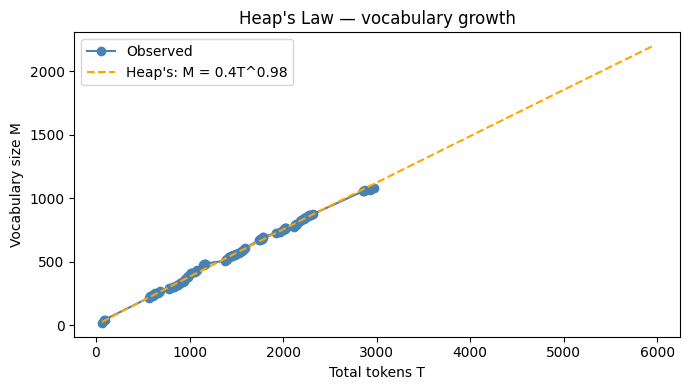

In [14]:
# 3b. Heap's Law — observe vocabulary growth as we add more documents
vocab_sizes = []
cumulative_vocab = set()
cumulative_tokens = []

for e in MINI_CORPUS:
    text   = normalize(get_primary_text(e))
    tokens = text.split()
    cumulative_tokens.extend(tokens)
    cumulative_vocab.update(tokens)
    vocab_sizes.append((len(cumulative_tokens), len(cumulative_vocab)))

T_vals = [v[0] for v in vocab_sizes]
M_vals = [v[1] for v in vocab_sizes]

print(f"{'Caption (first 22 chars)':<24} {'Total tokens':>14} {'Vocab size':>12} {'New terms':>12}")
print("-" * 66)
prev = 0
SHOW = 15  # show first N to keep output readable
for (t, m), e in zip(vocab_sizes[:SHOW], MINI_CORPUS[:SHOW]):
    print(f"{e['caption'][:22]:<24} {t:>14} {m:>12} {m-prev:>12}")
    prev = m
if len(MINI_CORPUS) > SHOW:
    (t_last, m_last) = vocab_sizes[-1]
    print(f"  ... ({len(MINI_CORPUS) - SHOW} more records) ...")
    print(f"{'[all 100 records]':<24} {t_last:>14} {m_last:>12}")

# Simulate Heap's Law: M = k * T^b
# Fit on log scale
if len(T_vals) >= 3:
    log_T = np.log(T_vals)
    log_M = np.log(M_vals)
    b, log_k = np.polyfit(log_T, log_M, 1)
    k = np.exp(log_k)
    print(f"\nFitted Heap's Law: M ≈ {k:.1f} × T^{b:.2f}")
    print(f"(Typical values: k ≈ 10-100, b ≈ 0.4-0.6)")

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(T_vals, M_vals, 'o-', color='steelblue', label='Observed')
if len(T_vals) >= 3:
    T_fit = np.linspace(min(T_vals), max(T_vals)*2, 100)
    ax.plot(T_fit, k * T_fit**b, '--', color='orange', label=f"Heap's: M = {k:.1f}T^{b:.2f}")
ax.set_xlabel('Total tokens T')
ax.set_ylabel('Vocabulary size M')
ax.set_title("Heap's Law — vocabulary growth")
ax.legend()
plt.tight_layout()
plt.show()

---
## Section 4: Full Preprocessing Pipeline

Putting it all together — the cell below calls the **same** `build_document` + `TextProcessor` as Phase 2 (`src/preprocessing/document_builder.py`, `src/preprocessing/pipeline.py`) for 1.24 M records. The educational steps in Sections 2–3 above illustrate tokenisation and statistics; they are not reimplemented here.

**Design decisions for OpenSanctions (see source for full field lists):**

| Field type | Tokenize? | Normalize? | Stop words? | Lemmatize? |
|-----------|-----------|-----------|------------|----------|
| `name`, `alias`, `previousName`, … | ✓ | ✓ | ✗ (names are meaningful) | ✗ (proper nouns) |
| `notes`, `description`, `summary` | ✓ | ✓ | ✓ | ✓ |
| `topics`, `sector`, `keywords`, … (keyword path) | ✓ | ✓ | ✗ | ✗ |
| Nested `sanctions`, `addressEntity` | ✓ | ✓ | per-field | per-field |
| **`programId`** | — | — | — | **Not in `text_blob`** — stored only under `metadata.programId` (and merged from nested sanctions) for exact filtering |
| **Identifiers** (IMO, MMSI, LEI, email, …) | ✗ (preserve raw) | ✗ | ✗ | ✗ — full list in `_IDENTIFIER_FIELDS` in `document_builder.py` |

Topics from `properties.topics` contribute to `text_blob` via the keyword pipeline; they are **not** duplicated as `metadata.topics` in Phase 2 output.

In [15]:
# Phase 2 pipeline — import production build_document (no duplicate logic here)
import os
import sys
from pathlib import Path


def _find_project_root() -> Path:
    """Walk upward from cwd until data/raw_data exists (same idea as scripts/build_index.py)."""
    marker = Path("data") / "raw_data"
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / marker).is_dir():
            return p
    for key in ("IR_PROJECT_ROOT", "VSCODE_WORKSPACE_FOLDER", "CURSOR_WORKSPACE_FOLDER"):
        v = os.environ.get(key)
        if v:
            cand = Path(v).expanduser().resolve()
            if (cand / marker).is_dir():
                return cand
    raise FileNotFoundError(
        "Cannot find project root (no data/raw_data). Set IR_PROJECT_ROOT or open the notebook from the repo."
    )


_ROOT = _find_project_root()
if str(_ROOT) not in sys.path:
    sys.path.insert(0, str(_ROOT))

from src.preprocessing.document_builder import build_document
from src.preprocessing.text_processing import TextProcessor

tp = TextProcessor()
PROCESSED_DOCS = [build_document(e, tp) for e in MINI_CORPUS]

print(f"Project root: {_ROOT}")
print(f"Sample record keys: {list(PROCESSED_DOCS[0].keys())}")
print(f"\n=== Processed {len(PROCESSED_DOCS)} Documents ===\n")
for doc in PROCESSED_DOCS[:5]:
    print(f"{doc['doc_id'][:22]:22} [{doc['schema']:<12}] {doc['caption'][:35]}")
    print(f"  tokens ({len(doc['tokens']):3d}): {doc['tokens'][:8]}")
    if doc['identifiers']:
        print(f"  identifiers: {doc['identifiers']}")
    print()
print(f"  ... ({len(PROCESSED_DOCS) - 5} more documents)")

Project root: /Users/alireza/Library/CloudStorage/GoogleDrive-ali.esterabi@gmail.com/My Drive/QMUL_temr_2/IR_project
Sample record keys: ['doc_id', 'caption', 'schema', 'text_blob', 'tokens', 'identifiers', 'metadata', 'first_seen', 'last_seen']

=== Processed 100 Documents ===

NK-223CQDBzp8MRkdJMDiq [Company     ] Myanmar Yatai International Holding
  tokens ( 94): ['yatai', 'new', 'city', 'myanmar', 'yatai', 'international', 'holding', 'group']
  identifiers: {'registrationNumber': ['103919088'], 'uniqueEntityId': ['PW2XZT68KVW9', 'PW3LMJ5YB3M3', 'PW2USM6LNCJ9', 'GQBPAV1TFF41']}

NK-223yQP6hRaMuiALDCJ6 [Company     ] Товариство з обмеженою відповідальн
  tokens ( 29): ['товариство', 'обмеженою', 'відповідальністю', 'зелінський', 'групп', 'общество', 'ограниченной', 'ответственностью']
  identifiers: {'innCode': ['7725491052'], 'ogrnCode': ['1187746408761'], 'kppCode': ['772501001']}

NK-224TRezPqwzhQZ37exW [Person      ] SANAVBARI NIKITENKO
  tokens ( 16): ['sanavbari', 'nikitenko',

In [16]:
# Pipeline validation — visualise step-by-step transformation for one real entity
# Pick the first record that has non-empty description text
e = next((r for r in MINI_CORPUS if get_desc(r)), MINI_CORPUS[0])
raw = get_desc(e) or ' '.join(get_names(e))  # fallback to names if no description

print(f"=== Step-by-step pipeline for: {e['caption'][:45]} ===")
print(f"Schema: {e['schema']}   |   ID: {e['id'][:30]}")
print(f"\nRaw text: {raw[:90]!r}{'...' if len(raw) > 90 else ''}")

step1 = raw.split()
print(f"\nStep 1 — tokenize (naive): {step1[:10]}{'...' if len(step1) > 10 else ''}")

step2 = normalize(raw).split()
print(f"Step 2 — normalize: {step2[:10]}{'...' if len(step2) > 10 else ''}")

step3 = remove_stopwords(step2)
print(f"Step 3 — remove stop words: {step3[:10]}{'...' if len(step3) > 10 else ''}")

# Demo lemmatisation (same pattern as free-text handling in TextProcessor — not the full Phase 2 assembler)
_doc = nlp(normalize(raw))
step4 = [t.lemma_ for t in _doc if t.is_alpha and not t.is_stop and len(t.text) > 1]
print(f"Step 4 — lemmatize: {step4[:10]}{'...' if len(step4) > 10 else ''}")

print(f"\nFinal token count: {len(step4)} (from {len(step1)} raw)")

=== Step-by-step pipeline for: Myanmar Yatai International Holding Group Co. ===
Schema: Company   |   ID: NK-223CQDBzp8MRkdJMDiqXn3

Raw text: '(also SHWE KOKKO SPECIAL ECONOMIC ZONE, YATAI NEW CITY, YATAI SMART INDUSTRIAL NEW CITY) ('...

Step 1 — tokenize (naive): ['(also', 'SHWE', 'KOKKO', 'SPECIAL', 'ECONOMIC', 'ZONE,', 'YATAI', 'NEW', 'CITY,', 'YATAI']...
Step 2 — normalize: ['also', 'shwe', 'kokko', 'special', 'economic', 'zone', 'yatai', 'new', 'city', 'yatai']...
Step 3 — remove stop words: ['also', 'shwe', 'kokko', 'special', 'economic', 'zone', 'yatai', 'new', 'city', 'yatai']...
Step 4 — lemmatize: ['shwe', 'kokko', 'special', 'economic', 'zone', 'yatai', 'new', 'city', 'yatai', 'smart']...

Final token count: 20 (from 22 raw)


In [17]:
# Save PROCESSED_DOCS for use in the next notebook
import json
with open('/tmp/mini_corpus_processed.json', 'w') as f:
    json.dump(PROCESSED_DOCS, f, indent=2)
print('Saved processed docs to /tmp/mini_corpus_processed.json')
print('Load this in 02_indexing_boolean_retrieval.ipynb to continue.')

Saved processed docs to /tmp/mini_corpus_processed.json
Load this in 02_indexing_boolean_retrieval.ipynb to continue.


In [18]:
# ── Save flattened documents to data/toy_example/ ─────────────────────────
# This JSONL file is the shared "running example" used by all learning notebooks.
# Derive output path from SAMPLE_PATH so it always resolves correctly.
OUT_DIR  = SAMPLE_PATH.parents[1] / "toy_example"   # data/raw_data → data → toy_example
OUT_DIR.mkdir(parents=True, exist_ok=True)
OUT_PATH = OUT_DIR / "documents.jsonl"

with OUT_PATH.open("w", encoding="utf-8") as f:
    for doc in PROCESSED_DOCS:
        f.write(json.dumps(doc, ensure_ascii=False) + "\n")

print(f"Saved {len(PROCESSED_DOCS)} flattened documents → {OUT_PATH}")
print()
print("Schema of each saved record (Phase 2):")
print("  doc_id      — original OpenSanctions entity ID")
print("  caption     — human-readable primary name")
print("  schema      — entity type (Person / Company / Vessel / ...)")
print("  text_blob   — lemmatised / normalised searchable string (TF-IDF input)")
print("  tokens      — list of tokens derived from text_blob (BM25 input)")
print("  identifiers — raw ID fields (exact-match retrieval); see document_builder._IDENTIFIER_FIELDS")
print("  metadata    — country, programId, datasets (topics live in text_blob via keyword path, not metadata.topics)")
print("  first_seen, last_seen — record timestamps from OpenSanctions")
print()
print("Downstream: scripts/build_index.py (BM25 / TF-IDF / identifier); src/fusion/rrf.py merges ranked CSVs.")
print()
print("Load in any other notebook with:")
print("  from pathlib import Path")
print("  import json")
print("  docs = [json.loads(l) for l in Path('data/toy_example/documents.jsonl').open()]")

Saved 100 flattened documents → /Users/alireza/Library/CloudStorage/GoogleDrive-ali.esterabi@gmail.com/My Drive/QMUL_temr_2/IR_project/data/toy_example/documents.jsonl

Schema of each saved record (Phase 2):
  doc_id      — original OpenSanctions entity ID
  caption     — human-readable primary name
  schema      — entity type (Person / Company / Vessel / ...)
  text_blob   — lemmatised / normalised searchable string (TF-IDF input)
  tokens      — list of tokens derived from text_blob (BM25 input)
  identifiers — raw ID fields (exact-match retrieval); see document_builder._IDENTIFIER_FIELDS
  metadata    — country, programId, datasets (topics live in text_blob via keyword path, not metadata.topics)
  first_seen, last_seen — record timestamps from OpenSanctions

Downstream: scripts/build_index.py (BM25 / TF-IDF / identifier); src/fusion/rrf.py merges ranked CSVs.

Load in any other notebook with:
  from pathlib import Path
  import json
  docs = [json.loads(l) for l in Path('data/toy_ex

---
## Summary

| Step | What it does | Key decision for OpenSanctions |
|------|-------------|-------------------------------|
| Tokenization | Split text into terms | Use spaCy for free text, regex for names |
| Normalization | Lowercase + diacritics + punctuation | Critical for Cyrillic/Arabic names |
| Stop words | Remove high-frequency noise terms | Only from free text, never from names |
| Stemming | Rule-based suffix chopping (Porter) | Fast but lossy — not used in Phase 2 |
| Lemmatization | POS-aware base form | Used for notes/description in Phase 2 |
| Zipf's Law | Word frequency distribution | Explains why stop word removal works |
| Heap's Law | Vocabulary growth rate | Predicts index size scaling |

**After preprocess:** `documents.jsonl` feeds `scripts/build_index.py` (classical indices). Dense encoding is separate (`07a` notebook). **RRF** (`src/fusion/rrf.py`) combines **ranked run CSVs** from retrievers, not raw JSONL.

**Next:** `02_indexing_boolean_retrieval.ipynb` — take the tokens from this notebook and build an inverted index, then query it with Boolean, positional, and compressed retrieval.